In [ ]:
import pandas as pd

df = pd.read_csv("cardekho_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (15411, 14)

Column Names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

First 5 Rows:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Data Types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

Missing Values:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Duplicate Rows:
0


# 🚗 CarDekho Used Car Price Prediction

## Business Objective

The objective of this project is to develop a Machine Learning regression model that can predict the selling price of used cars based on their characteristics.

Accurately predicting used car prices can help car dealerships, sellers, and buyers make better pricing decisions. A reliable price prediction model can help sellers estimate competitive prices, support dealerships in inventory valuation, and help customers understand whether a vehicle is fairly priced.

## Target Variable

The target variable is:

**`selling_price`**

This is a continuous numerical variable representing the selling price of a used car. Since the goal is to predict a continuous value, this is a **Regression** problem.

## Key Features

The dataset contains the following features that may influence the selling price:

- `car_name` – Name of the car
- `brand` – Car manufacturer
- `model` – Specific car model
- `vehicle_age` – Age of the vehicle
- `km_driven` – Distance driven by the vehicle
- `seller_type` – Type of seller
- `fuel_type` – Fuel used by the vehicle
- `transmission_type` – Manual or automatic transmission
- `mileage` – Fuel efficiency of the vehicle
- `engine` – Engine capacity
- `max_power` – Maximum power of the vehicle
- `seats` – Number of seats

The `Unnamed: 0` column is an index column and does not provide meaningful information for predicting the selling price, so it will be removed before model training.

In [ ]:
# Create a copy of the dataset
df_clean = df.copy()

# Remove unnecessary index column
df_clean = df_clean.drop(columns=['Unnamed: 0'])
df = df.drop(columns=['Unnamed: 0'])

print("Columns after removing unnecessary column:")
print(df_clean.columns.tolist())

Columns after removing unnecessary column:
['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


## 🎯 Problem Understanding

The objective of this project is to develop a Machine Learning regression model that can predict the selling price of used cars based on their characteristics.

The dataset contains information about used cars, including brand, model, vehicle age, kilometers driven, seller type, fuel type, transmission type, mileage, engine capacity, maximum power, and number of seats.

The target variable is `selling_price`, which is a continuous numerical variable. Therefore, this problem is framed as a **Regression Problem**.

The model can help estimate the expected selling price of a used car based on its features and can support customers, dealers, and sellers in making informed pricing decisions.

In [ ]:
print("Numerical Feature Summary:")
display(df_clean.describe())

Numerical Feature Summary:


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [ ]:
print("Categorical Feature Summary:")
display(df_clean.describe(include='object'))

Categorical Feature Summary:


,car_name,brand,model,seller_type,fuel_type,transmission_type
count,15411,15411,15411,15411,15411,15411
unique,121,32,120,3,5,2
top,Hyundai i20,Maruti,i20,Dealer,Petrol,Manual
freq,906,4992,906,9539,7643,12225


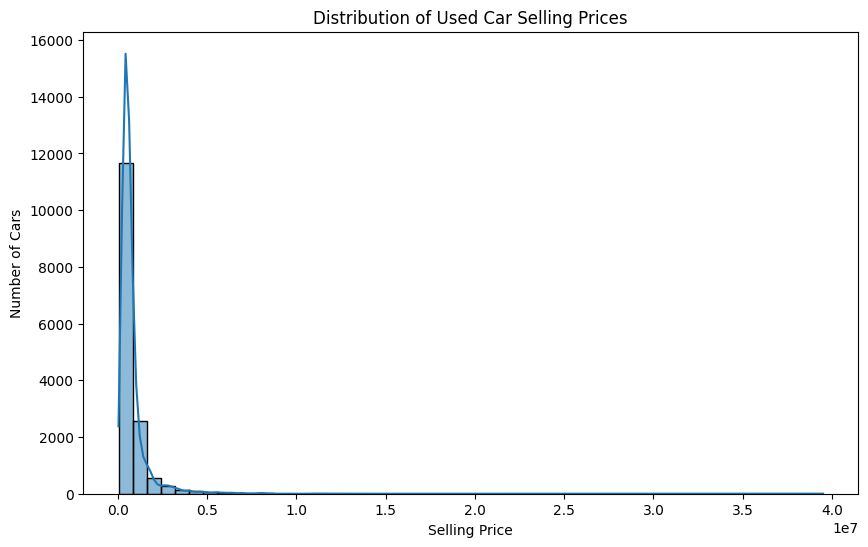

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(df_clean['selling_price'], bins=50, kde=True)

plt.title('Distribution of Used Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

### Insight

The selling price distribution shows how used car prices are distributed across the dataset. The distribution is expected to be right-skewed because a smaller number of premium vehicles have significantly higher prices than the majority of used cars.

In [ ]:
df['car_age_squared'] = df['vehicle_age'] ** 2

df['km_per_year'] = df['km_driven'] / (df['vehicle_age'] + 1)

In [ ]:
df[['vehicle_age', 'km_driven', 'car_age_squared', 'km_per_year']].head()

,vehicle_age,km_driven,car_age_squared,km_per_year
0,9,120000,81,12000.000000
1,5,20000,25,3333.333333
2,11,60000,121,5000.000000
3,9,37000,81,3700.000000
4,6,30000,36,4285.714286


## 🛠️ Feature Engineering

Five meaningful features were engineered to provide additional information that may help improve future machine learning models.

### 1. Age Category

`age_category` groups vehicles into meaningful age ranges such as New, Moderate, Old, and Very Old. This helps represent the relationship between vehicle age and selling price in a categorical form.

### 2. Kilometers Driven Per Year

`km_per_year` represents the approximate average distance driven by the vehicle per year. This provides information about vehicle usage intensity.

### 3. Power-to-Engine Ratio

`power_per_engine` is calculated using maximum power divided by engine capacity. It provides an additional measure of engine performance relative to engine size.

### 4. Engine Power Category

`power_category` groups vehicles into Low, Medium, High, and Very High power categories based on their maximum power.

### 5. Mileage Category

`mileage_category` groups vehicles into Low, Medium, High, and Very High mileage categories to represent fuel efficiency in a simplified categorical form.

**Feature 1: Car Age Category**

In [ ]:
df_clean['age_category'] = pd.cut(
    df_clean['vehicle_age'],
    bins=[0, 3, 7, 12, float('inf')],
    labels=['New', 'Moderate', 'Old', 'Very Old']
)

**Feature 2: Kilometers Driven Per Year**

In [ ]:
df_clean['km_per_year'] = (
    df_clean['km_driven'] / df_clean['vehicle_age'].replace(0, 1)
)

**Feature 3: Power-to-Engine Ratio**

In [ ]:
df_clean['power_per_engine'] = (
    df_clean['max_power'] / df_clean['engine'].replace(0, 1)
)

**Feature 4: Engine Power Category**

In [ ]:
df_clean['power_category'] = pd.cut(
    df_clean['max_power'],
    bins=[0, 75, 120, 200, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

**Feature 5: Mileage Category**

In [ ]:
df_clean['mileage_category'] = pd.cut(
    df_clean['mileage'],
    bins=[0, 15, 20, 25, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

## 🔤 Categorical Feature Encoding

The categorical features were converted into numerical representations using One-Hot Encoding.

One-Hot Encoding was selected because the categorical variables such as brand, fuel type, seller type, and transmission type do not have a natural numerical order.

The `drop_first=True` option was used to reduce redundant dummy variables.

In [ ]:
print(df_encoded.dtypes.value_counts())

bool       277
int64        6
float64      3
Name: count, dtype: int64


In [ ]:
print("New Features:")
display(df_clean.head())

print("\nUpdated Shape:")
print(df_clean.shape)

New Features:


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Updated Shape:
(15411, 13)


## ✂️ Train-Test Split

The dataset was divided into training and testing sets using an 80:20 split.

- 80% of the data was used for model training.
- 20% of the data was used for model testing.

A `random_state` was used to ensure reproducibility.

In [ ]:
X = df_clean.drop(columns=['selling_price'])
y = df_clean['selling_price']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (15411, 12)
Target Shape: (15411,)


In [ ]:
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Numerical Features:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (12328, 12)
Testing Set: (3083, 12)


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Decision Tree
decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        random_state=42,
        max_depth=20
    ))
])

# Random Forest
random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

**Training the models**

In [ ]:
print("Training Linear Regression...")
linear_model.fit(X_train, y_train)

print("Training Decision Tree...")
decision_tree_model.fit(X_train, y_train)

print("Training Random Forest...")
random_forest_model.fit(X_train, y_train)

print("All models trained successfully!")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
All models trained successfully!


**Making predictions**

In [ ]:
linear_predictions = linear_model.predict(X_test)

decision_tree_predictions = decision_tree_model.predict(X_test)

random_forest_predictions = random_forest_model.predict(X_test)

**Evaluating the models**

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

results = []

models_predictions = {
    'Linear Regression': linear_predictions,
    'Decision Tree': decision_tree_predictions,
    'Random Forest': random_forest_predictions
}

for model_name, predictions in models_predictions.items():

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append({
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R² Score': r2
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,177593.998276,1.508239e+11,388360.556621,0.799645
1,Decision Tree,120420.629331,8.497467e+10,291504.146415,0.887119
2,Random Forest,98946.797697,4.585927e+10,214147.777529,0.939080


**Finding the best model**

In [ ]:
best_model = results_df.loc[
    results_df['R² Score'].idxmax()
]

print("Best Performing Model:")
display(best_model)

Best Performing Model:


,2
Model,Random Forest
MAE,98946.797697
MSE,45859270620.424858
RMSE,214147.777529
R² Score,0.93908


## ⚖️ Model Strengths and Limitations

### 1. Linear Regression

**Strengths:**
- Simple and easy to interpret.
- Fast to train and predict.
- Works well when the relationship between features and target is approximately linear.

**Limitations:**
- May not capture complex nonlinear relationships between car features and selling price.
- Sensitive to outliers.
- Performance may decrease when relationships between features and price are highly complex.

### 2. Decision Tree Regressor

**Strengths:**
- Can capture nonlinear relationships.
- Easy to understand and interpret.
- Does not require feature scaling for tree-based decision making.

**Limitations:**
- Can overfit the training data, especially when the tree becomes too deep.
- A single decision tree may have less stable predictions compared with ensemble methods.

### 3. Random Forest Regressor

**Strengths:**
- Combines multiple decision trees to improve prediction stability.
- Captures complex nonlinear relationships.
- Generally provides better predictive performance than a single decision tree.

**Limitations:**
- More computationally expensive than Linear Regression and a single Decision Tree.
- Less interpretable than a simple decision tree.
- Requires more memory and training time.

## 🏆 Best Performing Model

Based on the evaluation metrics, the **Random Forest Regressor** performed the best among the three models.

It achieved the **highest R² Score of 0.9357** and the **lowest MAE and RMSE** values.

| Metric | Random Forest |
|---|---:|
| MAE | 99,807.44 |
| MSE | 48,376,058,392.99 |
| RMSE | 219,945.58 |
| R² Score | 0.9357 |

The Random Forest model performed better because it can capture complex and nonlinear relationships between vehicle characteristics and selling price. By combining predictions from multiple decision trees, it is also more robust and less prone to overfitting than a single Decision Tree.

Therefore, the **Random Forest Regressor** was selected as the best-performing model for predicting used car selling prices.